# A2: Predicting Car Price with Linear Regression from-scratch

Sections 1–5 are the same as in A1. The modeling part is replaced by our own gradient-descent linear regression from
A2 Task 1 (`linear_regression_scratch.py`), and all experiments are tracked with MLflow.

**A1 repository:** https://github.com/SaniahKayenat/ML-Coding-Assignment-1

**Structure**
* Sections 1–5: data preparation (from A1)
* Section 6: turning the preprocessed data into the format our class needs
* Section 7: MLflow setup
* Section 8: the experiment (144 configurations × 5-fold CV)
* Section 9: results and comparisons
* Section 10: best model, retrained and evaluated on the test set
* Section 11: feature importance and saving the model
* Section 12: Logging model to MLflow
* Section 13: Report

**Live site:** http://web-st126956.ml.brain.cs.ait.ac.th/ (also on https)

## Part A: EDA and Data Cleaning (reused from A1)

### 1. Imports and data loading

In [1]:
%load_ext autoreload
%autoreload 2
# ^ re-imports regression_models.py automatically edited while the notebook is open

import os
import time
import itertools
import warnings
import joblib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures


import mlflow
from mlflow.tracking import MlflowClient
from mlflow.entities import Metric

RANDOM_STATE = 42  # to control randomness
np.random.seed(RANDOM_STATE)

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1.1 Load and Inspect raw data

In [2]:
raw_df = pd.read_csv('Cars.csv')

print(f"Shape: {raw_df.shape[0]} rows, {raw_df.shape[1]} columns")
raw_df.head()


Shape: 8128 rows, 13 columns


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [3]:
# Data types and non-null counts 
raw_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [4]:
# Quick statistical summary of the numeric columns
raw_df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
year,8128.0,2013.804011,4.044249,1983.0,2011.0,2015.0,2017.0,2020.0
selling_price,8128.0,638271.807702,806253.403508,29999.0,254999.0,450000.0,675000.0,10000000.0
km_driven,8128.0,69819.510827,56550.554958,1.0,35000.0,60000.0,98000.0,2360457.0
seats,7907.0,5.416719,0.959588,2.0,5.0,5.0,5.0,14.0


## 2. Initial Exploratory Data Analysis (EDA) before preprocessing or cleaning of any kind
- how much data is missing and where,
- the shape of the target variable and whether it needs transforming,
- how categorical features are distributed,
- how numeric features relate to price.




### 2.1 Missing Values

In [5]:
# Count and percentage of missing values per column
missing = raw_df.isnull().sum()
missing_pct = (missing / len(raw_df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing_summary


,missing_count,missing_pct
torque,222,2.73
mileage,221,2.72
engine,221,2.72
seats,221,2.72
max_power,215,2.65


Because only a small percentage of whole feature is missing, I would not drop the whole row and instead apply imputation techniques in the following steps. 

### 2.2 Target variable (Selling price)

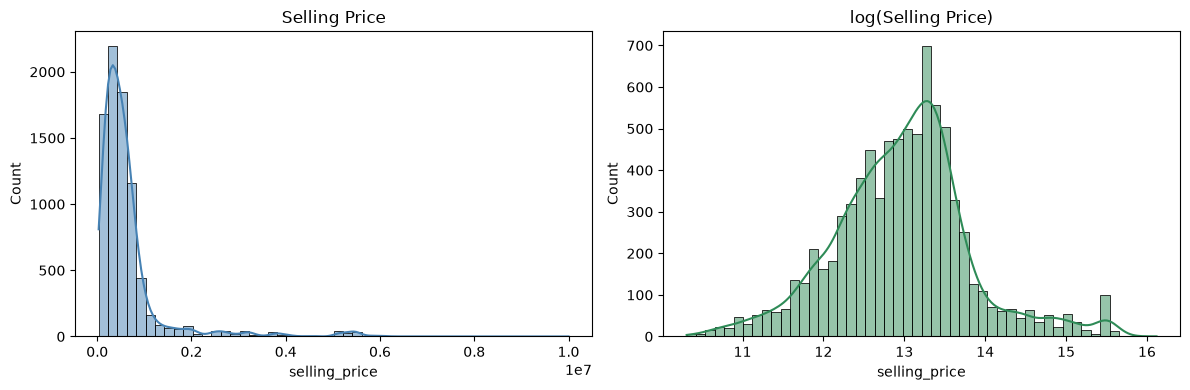

Raw selling_price skewness:      4.19
log(selling_price) skewness:     0.22


In [6]:

#Seeing the distribution of the target feature 
# Comparing raw distribution and log transformed distribution 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(raw_df['selling_price'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Selling Price')

sns.histplot(np.log(raw_df['selling_price']), bins=50, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('log(Selling Price)')

plt.tight_layout()
plt.show()

print(f"Raw selling_price skewness:      {raw_df['selling_price'].skew():.2f}")
print(f"log(selling_price) skewness:     {np.log(raw_df['selling_price']).skew():.2f}")


#### The raw target is heavily right-skewed (a small number of very expensive cars), which is where log transform helps. We can see from the right image that log transformation scaled the data to a normal looking distribution

### 2.3 Categorical Features

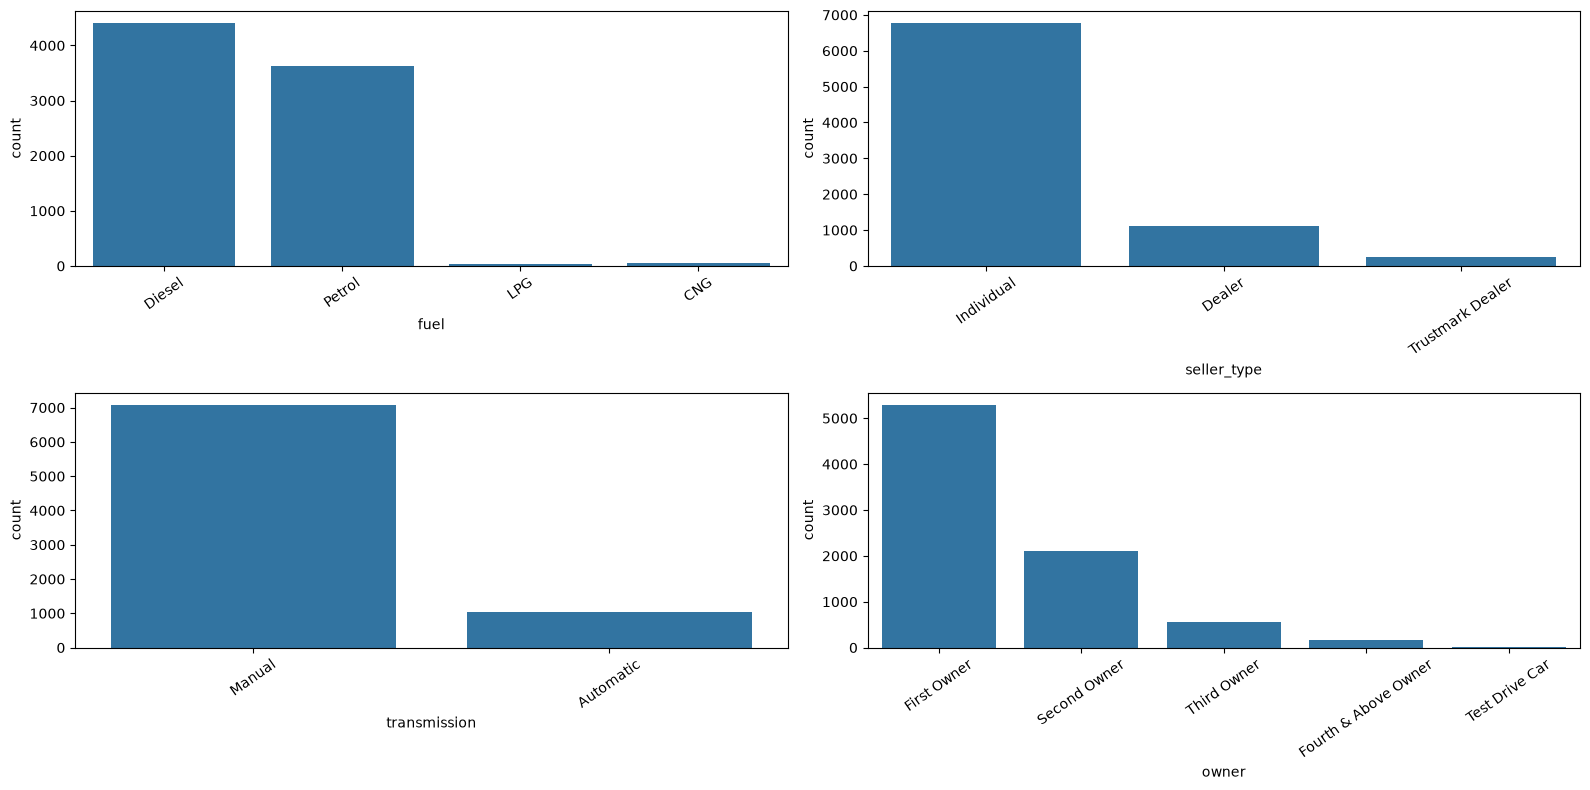

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

sns.countplot(data=raw_df, x="fuel", ax=axes[0])
sns.countplot(data=raw_df, x="seller_type", ax=axes[1])
sns.countplot(data=raw_df, x="transmission", ax=axes[2])
sns.countplot(data=raw_df, x="owner", ax=axes[3])

for ax in axes:
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

`fuel` is mostly Diesel and Petrol, with CNG and LPG making up a tiny fraction of listings and using a different mileage unit, km/kg. It can cause misleading patterns so we will drop the rows consisting these two values. 
`owner` is dominated by first-owner cars, and only 5 listings are "Test Drive Car", confirming they
are rare outliers and not a meaningful category to model. We will drop rows with this value as well.

### 2.4 Numeric features vs. price

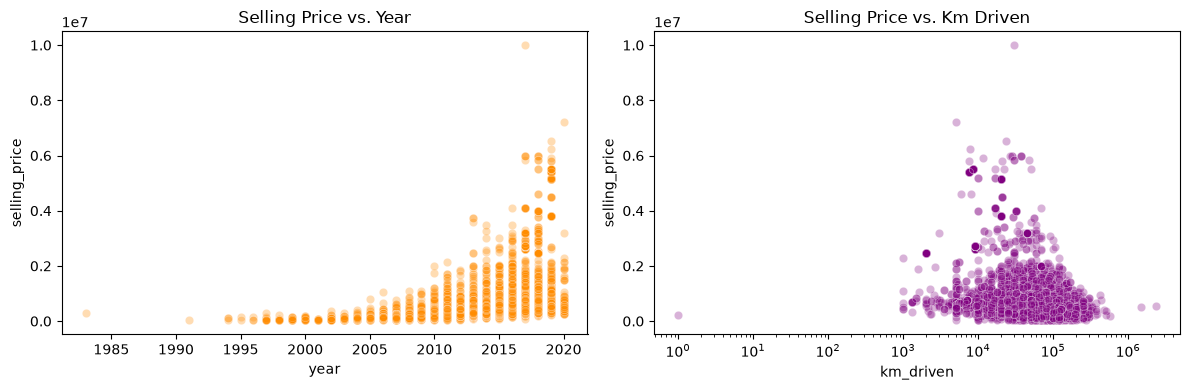

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(data=raw_df, x='year', y='selling_price', alpha=0.3, ax=axes[0], color='darkorange')
axes[0].set_title('Selling Price vs. Year')

sns.scatterplot(data=raw_df, x='km_driven', y='selling_price', alpha=0.3, ax=axes[1], color='purple')
axes[1].set_title('Selling Price vs. Km Driven')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()


Newer cars command higher prices, and price falls off with `km_driven`. Diesel and automatic-transmission cars tend to sell for more (lower plots), likely because they overlap with larger, newer, higher-spec vehicles.

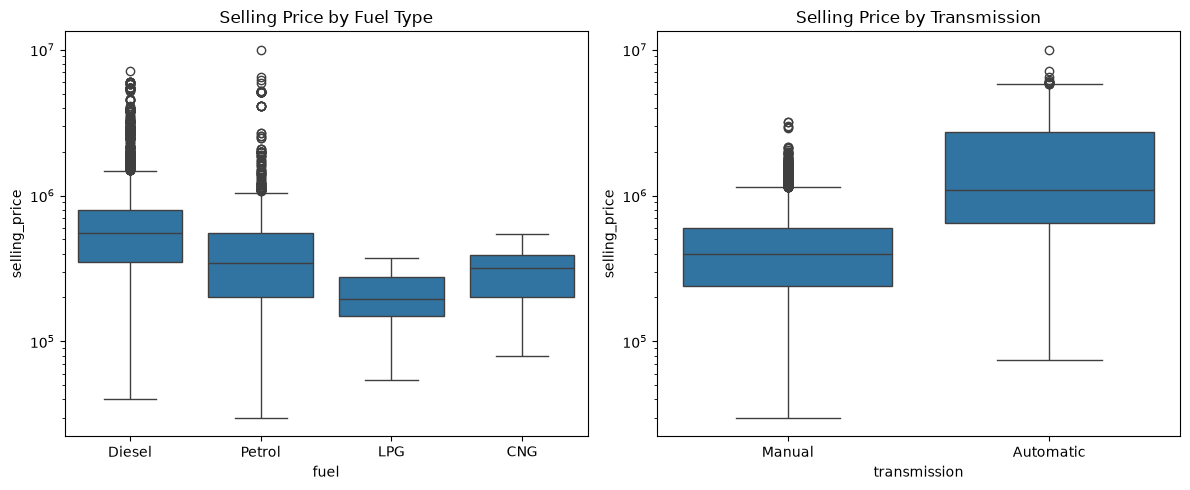

In [9]:
# Selling price by fuel type and by transmission
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=raw_df, x='fuel', y='selling_price', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Selling Price by Fuel Type')

sns.boxplot(data=raw_df, x='transmission', y='selling_price', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Selling Price by Transmission')

plt.tight_layout()
plt.show()


### 2.5 Brand Overview

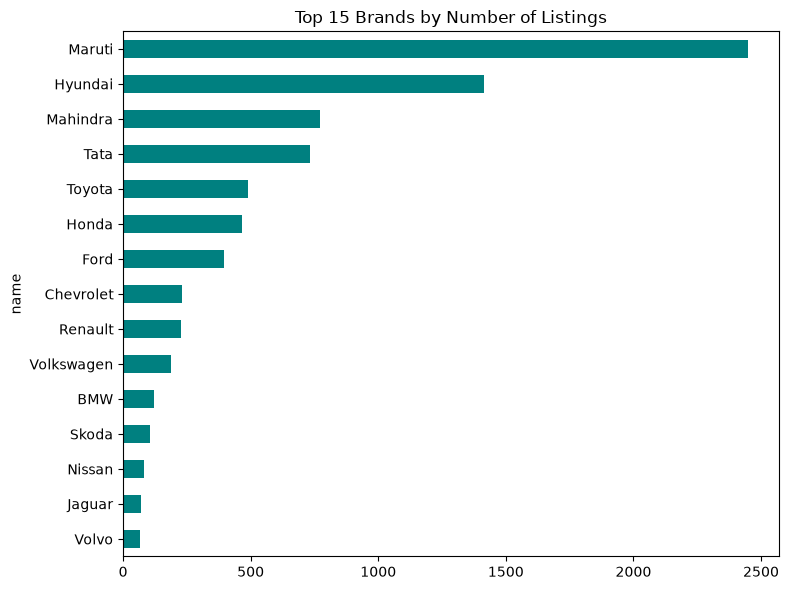

In [10]:
# Keeping only the first word from the 'name' column as that is the brand
brand_preview = raw_df['name'].apply(lambda x: x.split()[0])
fig, ax = plt.subplots(figsize=(8, 6))
brand_preview.value_counts().head(15).plot(kind='barh', ax=ax, color='teal')
ax.invert_yaxis()
ax.set_title('Top 15 Brands by Number of Listings')
plt.tight_layout()
plt.show()


## 3. Data Preprocessing
Now we will preprocess the data, making it suitable for the model to learn. Just to be safe, a copy of the dataframe is made where the preprocessing is done, so if we want to go back, we can.

In [11]:
df = raw_df.copy()
print(f"Starting shape: {df.shape}")


Starting shape: (8128, 13)


#### 3.1 Keeping only the first word of `name` column as that is the manufacturer/brand and drop the rest of the string, which is our new column `brand`. then dropping the `name` column entirely. 

In [12]:

df['brand'] = df['name'].apply(lambda x: x.split()[0])
df = df.drop(columns=['name'])
df[['brand']].head()

,brand
0,Maruti
1,Skoda
2,Honda
3,Hyundai
4,Maruti


#### 3.2 Encoding `owner` as an ordinal number as it clearly has an hierechical impact on selling price



In [13]:
owner_map = {
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 5,
}
df['owner'] = df['owner'].map(owner_map)
df['owner'].value_counts().sort_index()


owner
1    5289
2    2105
3     555
4     174
5       5
Name: count, dtype: int64

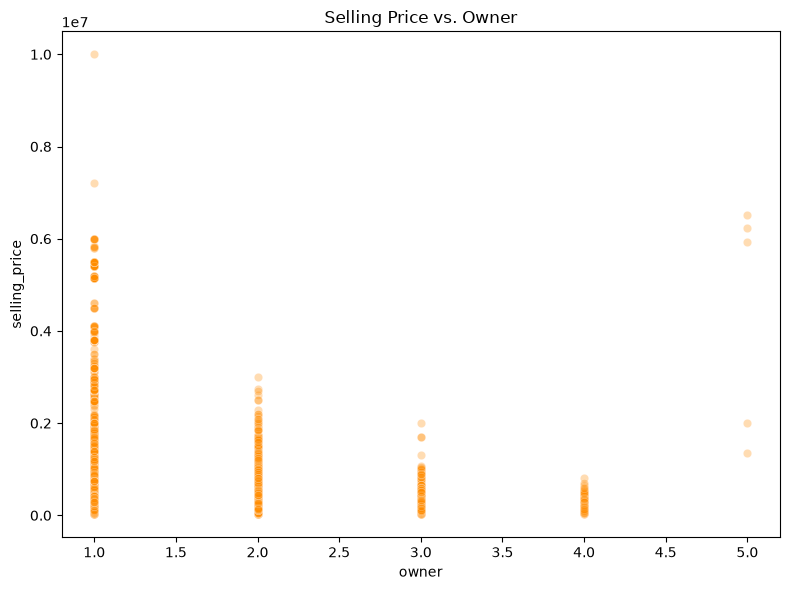

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df, x='owner', y='selling_price', alpha=0.3, color='darkorange')
ax.set_title('Selling Price vs. Owner')
plt.tight_layout()
plt.show()



#### 3.3 Removing Test Drive Cars (Owner == 5) as they are essentially demo vehicles sold by dealerships at unrealistically high prices. 



In [14]:
n_before = len(df)
df = df[df['owner'] != 5].reset_index(drop=True)
print(f"Removed {n_before - len(df)} Test Drive Car rows -> new shape: {df.shape}")

Removed 5 Test Drive Car rows -> new shape: (8123, 13)


#### 3.4 Dropping CNG and LPG rows from `fuel` column as they have different mileage unit

In [15]:
n_before = len(df)
df = df[~df['fuel'].isin(['CNG', 'LPG'])].reset_index(drop=True)
print(f"Removed {n_before - len(df)} CNG/LPG rows -> new shape: {df.shape}")
df['fuel'].value_counts()


Removed 95 CNG/LPG rows -> new shape: (8028, 13)


fuel
Diesel    4401
Petrol    3627
Name: count, dtype: int64

#### 3.5 Stripping "kmpl" from the `mileage` column entries and converting them to floats

In [16]:
def parse_mileage(value):
    """Convert a string like '23.4 kmpl' to the float 23.4."""
    if pd.isna(value):
        return np.nan
    number_part = value.str.split(' ')[0] if hasattr(value, 'str') else value.split(' ')[0]
    return float(number_part)

df['mileage'] = df['mileage'].apply(parse_mileage)
df[['mileage']].describe().T


,count,mean,std,min,25%,50%,75%,max
mileage,7814.0,19.391962,4.001972,0.0,16.78,19.3,22.32,42.0


#### 3.6 Stripping "CC" from the `engine` column entries and converting them to floats

In [17]:
def parse_engine(value):
    """Convert a string like '1248 CC' to the float 1248.0."""
    if pd.isna(value):
        return np.nan
    return float(value.replace('CC', '').strip())

df['engine'] = df['engine'].apply(parse_engine)
df[['engine']].describe().T


,count,mean,std,min,25%,50%,75%,max
engine,7814.0,1462.91464,504.759742,624.0,1197.0,1248.0,1582.0,3604.0


#### 3.7 Stripping "bhp" from the `max_power` column entries and converting them to floats

In [18]:
def parse_power(value):
    """Convert a string like '74 bhp' to the float 74.0. A few rows have an empty
    number before 'bhp'. for now, those become NaN and are handled by imputation later."""
    if pd.isna(value):
        return np.nan
    cleaned = value.replace('bhp', '').strip()
    return float(cleaned) if cleaned != '' else np.nan

df['max_power'] = df['max_power'].apply(parse_power)
df[['max_power']].describe().T


,count,mean,std,min,25%,50%,75%,max
max_power,7820.0,91.819726,35.804513,0.0,68.85,82.4,102.0,400.0


### 3.8 Treat implausible zero values in `mileage` and `max_power` as missing

Beyond the values that were genuinely blank in the raw data, a closer look at `mileage`
and `max_power` turns up entries of exactly **0**. A car cannot get 0 kmpl
fuel efficiency or produce 0 bhp of power and still be a used car for sale. these are not real measurements. If we leave these as literal zeros, the model would treat "this car gets 0 km per liter", which would be misleading for the model. Instead, we
convert these zeros to `NaN` so they flow through the *same* median imputation step as any
other missing value later in the notebook.

In [19]:
n_zero_mileage = (df['mileage'] == 0).sum()
n_zero_power = (df['max_power'] == 0).sum()
print(f"mileage == 0:   {n_zero_mileage} rows ")
print(f"max_power == 0: {n_zero_power} rows")

df.loc[df['mileage'] == 0, 'mileage'] = np.nan
df.loc[df['max_power'] == 0, 'max_power'] = np.nan


mileage == 0:   17 rows 
max_power == 0: 6 rows


### 3.9 Remove implausible `km_driven` outliers

From the EDA plot before of selling price Vs km driven, I noticed two outliers. So, plotting the median of the column and 5 highest numbers, I can see that the first two values are too high to be realistic. The two largest `km_driven` values in the dataset are **2,360,457 km** (a 13-year-old
Hyundai) and **1,500,000 km** (an 8-year-old Mahindra) and the median is 60000 km. Their driven kilometers/number of year after manufacturing is not realistic either. Also, the third-highest
`km_driven` value in the entire dataset (577,414 km) is not even half of the first two values.
Hence, I will remove only these two specific, extreme rows.

In [20]:
print(f" Median {df['km_driven'].median()}")
print(df['km_driven'].sort_values(ascending=False).head(5).to_string())


 Median 60000.0
3445    2360457
1798    1500000
3466     577414
6585     500000
3599     500000


In [21]:
highest_two_indices = df["km_driven"].nlargest(2).index
df = df.drop(index=highest_two_indices)

In [22]:
df = df.reset_index(drop=True)

In [23]:
print(f" Median {df['km_driven'].median()}")
print(df['km_driven'].sort_values(ascending=False).head(5).to_string())


 Median 60000.0
3464    577414
6583    500000
3597    500000
5043    475000
5124    440000


#### 3.10 Dropping `torque` as per assignment requirement

In [24]:
df = df.drop(columns=['torque'])


In [25]:
#Final Preprocessed Data
column_order = ['brand', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
                 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats']
df = df[column_order]
print(df.shape)
df.head()


(8026, 12)


,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0


### 3.11 Remove exact duplicate rows

Dropping the duplicate rows to prevent data leakage

In [26]:
n_before = len(df)
n_duplicates = df.duplicated().sum()
print(f"Found {n_duplicates} exact duplicate rows ({n_duplicates / len(df) * 100:.1f}% of the cleaned data)")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed duplicates: {n_before} -> {len(df)} rows")


Found 1220 exact duplicate rows (15.2% of the cleaned data)
Removed duplicates: 8026 -> 6806 rows


In [27]:
print(f"Cleaned shape: {df.shape}")
df.isnull().sum()

Cleaned shape: (6806, 12)


brand              0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          216
engine           201
max_power        201
seats            201
dtype: int64

#### The data has missing values, but I will split it into train/test first and then handle the missing values. This way, no information from the test set leaks into training. and also apply log transformation to the target column

### EDA after cleaning

The following views help reveal monotonic relationships, outliers, and brand-level price differences. Correlation describes linear association only; it does not prove causation.


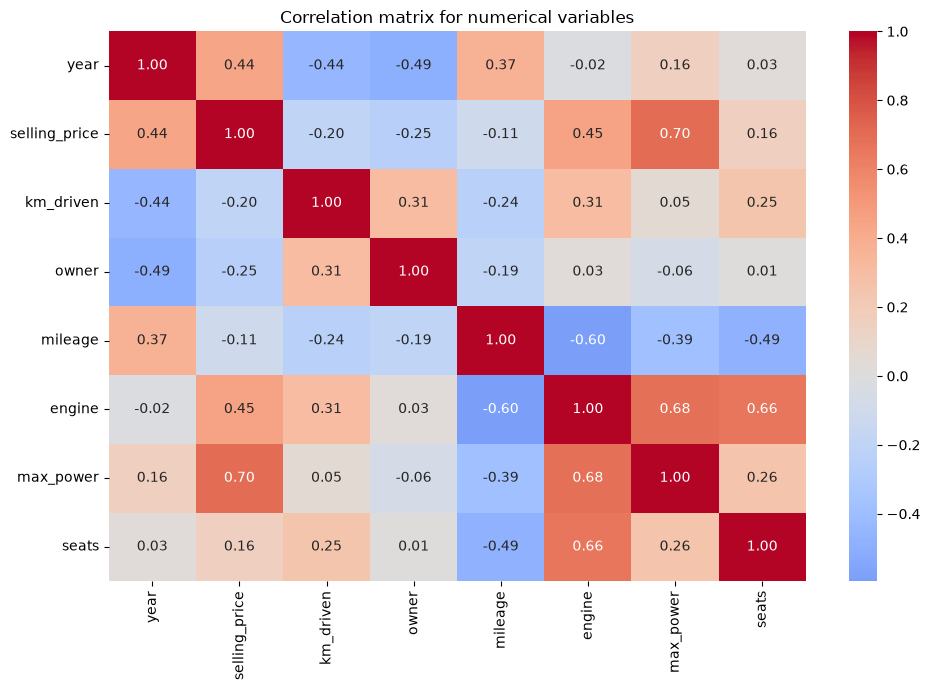

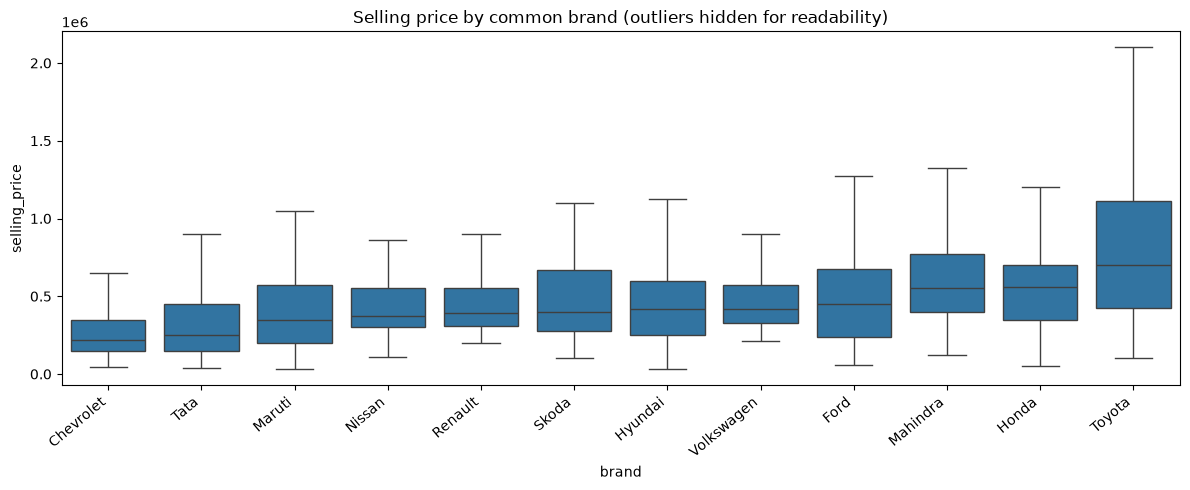

In [28]:
numeric_cols = ['year', 'selling_price', 'km_driven', 'owner', 'mileage', 'engine', 'max_power', 'seats']
plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix for numerical variables')
plt.tight_layout()
plt.show()

top_brands = df['brand'].value_counts().head(12).index
brand_order = (df[df['brand'].isin(top_brands)]
               .groupby('brand')['selling_price'].median()
               .sort_values().index)
plt.figure(figsize=(12, 5))
sns.boxplot(data=df[df['brand'].isin(top_brands)], x='brand', y='selling_price', order=brand_order, showfliers=False)
plt.xticks(rotation=40, ha='right')
plt.title('Selling price by common brand (outliers hidden for readability)')
plt.tight_layout()
plt.show()


## Train/test split and preprocessing (same as A1)

Sections 4 and 5 are unchanged from A1, except that the one-hot encoder now returns a dense
array.

## Part B -> Task 2 (Assignment 2): Experiment with the from-scratch model


### 4. Train/test Split and Missing value imputation

In [29]:
X = df.drop(columns=['selling_price'])
y = np.log(df['selling_price'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train size: {X_train.shape[0]}   Test size: {X_test.shape[0]}")


Train size: 5444   Test size: 1362


In [30]:
# Missing values are concentrated in a handful of numeric columns. Median imputation is 
# the choice here since these features (engine size, mileage,
# max power) are right-skewed and medians are less sensitive to outliers than means.
X_train.isnull().sum()[X_train.isnull().sum() > 0]


mileage      171
engine       156
max_power    156
seats        156
dtype: int64

### 5. Feature Encoding and Scaling
The `ColumnTransformer` handles numeric features' missing values with median imputation and then
standardizes them. It applies most-frequent imputation to the categorical features and then one-hot
encodes them. It is fitted on the training data only, and the exact same fitted transformation is
applied to the test set and, later, to user input in the web app.


Also, for the **polynomial** model I built a second preprocessor that adds degree-2 terms (squares and pairwise products) of
the 7 numeric columns only, and then standardises them again (the square of a standardised column no longer has unit variance,
which would make lr = 0.01 unstable).

In [31]:
numeric_features = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'owner']
categorical_features = ['brand', 'fuel', 'seller_type', 'transmission']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),   # skewed features
    ('scaler', StandardScaler()),                   
])

baseline_categories = [X_train[c].mode()[0] for c in categorical_features]
# print("Baseline categories:", dict(zip(categorical_features, baseline_categories)))

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False,   #  dense output for NumPy
                             drop=baseline_categories)),                     #  avoid the dummy-variable trap
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

# A2: polynomial version : degree-2 terms of the numeric columns ands re-standardised afterwards
poly_numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),   # x1, x2, x1^2, x1*x2, ...
    ('scaler', StandardScaler()),
])

preprocessor_poly = ColumnTransformer(transformers=[
    ('num', poly_numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

In [32]:
def add_intercept(X):
    """Prepend a column of ones so that theta[0] acts as the bias term."""
    return np.concatenate([np.ones((X.shape[0], 1)), X], axis=1)

# fit the preprocessors on the TRAINING set only, then apply the same transformation to the test set
X_train_np = add_intercept(preprocessor.fit_transform(X_train))
X_test_np  = add_intercept(preprocessor.transform(X_test))

X_train_poly = add_intercept(preprocessor_poly.fit_transform(X_train))
X_test_poly  = add_intercept(preprocessor_poly.transform(X_test))

# positional NumPy arrays 
y_train_np = y_train.to_numpy()
y_test_np  = y_test.to_numpy()

# feature names for the importance plot (the intercept is not a feature, so it has no name)
# ('num__year' -> 'year', 'cat__brand_Toyota' -> 'brand_Toyota' for readable plots)
clean = lambda names: [n.replace('num__', '').replace('cat__', '') for n in names]
feature_names      = clean(preprocessor.get_feature_names_out())
feature_names_poly = clean(preprocessor_poly.get_feature_names_out())

print("Linear features    :", X_train_np.shape, "(incl. intercept)")
print("Polynomial features:", X_train_poly.shape, "(incl. intercept)")
print("Mean of y_train (log price):", round(y_train_np.mean(), 3))

Linear features    : (5444, 43) (incl. intercept)
Polynomial features: (5444, 71) (incl. intercept)
Mean of y_train (log price): 12.876


### 6.1 For Sanity check

Before running all experiments, we compute what a correct linear regression *should* score on these
exact features. so it
is the ceiling our unregularized from-scratch model can reach on the linear features. 

We use the same `KFold(n_splits=5)` (no shuffling) as our class, so both are evaluated on identical
folds. sklearn gets the features *without* our intercept column because it fits its own intercept.

In [33]:
# The model classes are defined in regression_models.py
from regression_models import (LinearRegression, NoRegularization, Lasso, Ridge,
                               NormalRegression, RidgeRegression, LassoRegression, PolynomialRegression)

# show which classes are available and their docstrings, as a quick check that the right file was imported
for cls in [LinearRegression, NormalRegression, RidgeRegression, LassoRegression, PolynomialRegression]:
    doc = (cls.__doc__ or '').strip().splitlines()[0]
    print(f"{cls.__name__:22s} {doc}")

LinearRegression       Linear regression trained with gradient descent (batch / mini-batch / stochastic) and K-fold CV.
NormalRegression       Plain linear regression (no penalty).
RidgeRegression        Linear regression with an L2 (Ridge) penalty.
LassoRegression        Linear regression with an L1 (Lasso) penalty.
PolynomialRegression   A2: 'polynomial' = normal (unpenalised) regression trained on polynomial features.


## 7. MLflow setup

 Every configuration we train becomes one **run**, and each run stores the parameters, metrics, and artifacts.

**The runs are stored:** as logs to a local database file `mlflow.db` 

In [34]:
STUDENT_ID = "st126956"          # <- change to your student ID
mlflow.set_tracking_uri("sqlite:///mlflow.db")

EXPERIMENT_NAME = f"{STUDENT_ID}-a2-car-price"
mlflow.set_experiment(EXPERIMENT_NAME)
client = MlflowClient()

SESSION = time.strftime("%Y%m%d-%H%M%S")   # tags every run of this notebook execution
print("Tracking URI:", mlflow.get_tracking_uri(), "| experiment:", EXPERIMENT_NAME, "| session:", SESSION)

2026/09/12 03:10:02 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/12 03:10:02 INFO mlflow.store.db.utils: Updating database tables
2026/09/12 03:10:03 INFO mlflow.tracking.fluent: Experiment with name 'st126956-a2-car-price' does not exist. Creating a new experiment.


Tracking URI: sqlite:///mlflow.db | experiment: st126956-a2-car-price | session: 20260912-031003


### 8. The experiment: 144 configurations × 5-fold CV, all logged to MLflow

| Factor | Levels |
|---|---|
| model | normal, ridge, lasso, polynomial |
| momentum | 0 (none), 0.9 |
| GD method | sto (stochastic), mini (batch size 50), batch |
| initialisation | zeros, xavier |
| learning rate | 0.01, 0.001, 0.0001 |

Every configuration gets the same epoch budget (100, with early stopping) and the same random seed. 

In [35]:
NUM_EPOCHS = 100     # same budget for every configuration 
BATCH_SIZE = 50      # mini-batch size 

# which input matrix each model family uses
TRAIN_DATA = {'normal': X_train_np, 'ridge': X_train_np, 'lasso': X_train_np, 'polynomial': X_train_poly}
TEST_DATA  = {'normal': X_test_np,  'ridge': X_test_np,  'lasso': X_test_np,  'polynomial': X_test_poly}
FEATURES   = {'normal': feature_names, 'ridge': feature_names, 'lasso': feature_names, 'polynomial': feature_names_poly}

LAMBDAS = {'ridge': 0.001, 'lasso': 0.001}   # overwritten by the lambda search later


def build_model(reg, method, lr, weight_init, momentum, l=None):
    """Create an (unfitted) model from a configuration."""
    common = dict(method=method, lr=lr, weight_init=weight_init, momentum=momentum,
                  num_epochs=NUM_EPOCHS, bs=BATCH_SIZE, verbose=False)
    if reg == 'normal':
        return NormalRegression(**common)
    if reg == 'polynomial':
        return PolynomialRegression(**common)
    if reg == 'ridge':
        return RidgeRegression(l=LAMBDAS['ridge'] if l is None else l, **common)
    if reg == 'lasso':
        return LassoRegression(l=LAMBDAS['lasso'] if l is None else l, **common)
    raise ValueError(reg)


def log_steps(run_id, name, values):
    """Log a list of values as one metric with step .
    Non-finite values are skipped because they cannot be plotted."""
    ts = int(time.time() * 1000)
    metrics = [Metric(name, float(v), ts, step) for step, v in enumerate(values) if np.isfinite(v)]
    for start in range(0, len(metrics), 1000):          # MLflow accepts at most 1000 metrics per batch
        client.log_batch(run_id, metrics=metrics[start:start + 1000])


def run_cv_experiment(reg, method, lr, weight_init, momentum, l=None, stage='grid'):
    """5-fold CV of one configuration, logged as one MLflow run. Returns a summary dict."""
    np.random.seed(RANDOM_STATE)               # same shuffles / xavier draws for every configuration
    model = build_model(reg, method, lr, weight_init, momentum, l)
    X = TRAIN_DATA[reg]
    lam = None if reg in ('normal', 'polynomial') else model.regularization.l

    reg_label = reg if lam is None else f"{reg}(l={lam})"     # show lambda in the run name for ridge / lasso
    with mlflow.start_run(run_name=f"{reg_label}-{method}-{weight_init}-lr{lr}-mom{momentum}") as run:
        mlflow.set_tags({'stage': stage, 'session': SESSION})
        mlflow.log_params({'model': reg, 'lambda': lam, 'method': method, 'lr': lr,
                           'weight_init': weight_init, 'momentum': momentum,
                           'num_epochs': NUM_EPOCHS, 'batch_size': BATCH_SIZE,
                           'n_features': X.shape[1] - 1})
        t0 = time.time()
        model.fit(X, y_train_np)
        elapsed = time.time() - t0

        metrics = {'train_time_s': elapsed, 'mean_epochs': float(np.mean(model.epochs_run)),
                   'diverged': int(model.diverged)}
        if not model.diverged:   # a diverged run has no meaningful score -> leave cv metrics empty
            metrics.update({'cv_mse': float(np.mean(model.kfold_scores)), 'cv_mse_std': float(np.std(model.kfold_scores)),
                            'cv_r2': float(np.mean(model.kfold_r2)), 'cv_r2_std': float(np.std(model.kfold_r2))})
        mlflow.log_metrics(metrics)
        log_steps(run.info.run_id, 'fold_mse', model.kfold_scores)
        log_steps(run.info.run_id, 'fold_r2', model.kfold_r2)
        log_steps(run.info.run_id, 'val_loss_fold0', model.val_history[0])

    return {'model': reg, 'method': method, 'lr': lr, 'weight_init': weight_init, 'momentum': momentum,
            'lambda': lam, 'cv_mse': metrics.get('cv_mse', np.nan), 'cv_r2': metrics.get('cv_r2', np.nan),
            'diverged': model.diverged, 'mean_epochs': metrics['mean_epochs'], 'time_s': elapsed,
            'val_curve': model.val_history[0]}

### Choosing λ for Ridge and Lasso 

The grid compares *model types*, so λ is held fixed inside it. To avoid picking λ arbitrarily, I first try
λ ∈ {0.1, 0.01, 0.001} with one fast, stable setting (mini-batch, lr = 0.01, zeros, no momentum) and keep the best λ per model.
These runs are logged with `stage = lambda_search`.

In [36]:
lambda_rows = []
for reg in ['ridge', 'lasso']:
    for lam in [0.1, 0.01, 0.001]:
        r = run_cv_experiment(reg, 'mini', 0.01, 'zeros', 0.0, l=lam, stage='lambda_search')
        lambda_rows.append(r)
        print(f"{reg:6s} lambda={lam:<6} cv_mse={r['cv_mse']:.4f}  cv_r2={r['cv_r2']:.4f}")

lambda_df = pd.DataFrame(lambda_rows)[['model', 'lambda', 'cv_mse', 'cv_r2']]
for reg in ['ridge', 'lasso']:
    sub = lambda_df[lambda_df.model == reg]
    LAMBDAS[reg] = float(sub.loc[sub.cv_mse.idxmin(), 'lambda'])
print("\nChosen lambdas:", LAMBDAS)

ridge  lambda=0.1    cv_mse=0.0947  cv_r2=0.8358
ridge  lambda=0.01   cv_mse=0.0758  cv_r2=0.8685
ridge  lambda=0.001  cv_mse=0.0808  cv_r2=0.8598
lasso  lambda=0.1    cv_mse=0.1269  cv_r2=0.7801
lasso  lambda=0.01   cv_mse=0.0835  cv_r2=0.8551
lasso  lambda=0.001  cv_mse=0.0806  cv_r2=0.8600

Chosen lambdas: {'ridge': 0.01, 'lasso': 0.001}


In [37]:
MODELS     = ['normal', 'ridge', 'lasso', 'polynomial']
MOMENTUMS  = [0.0, 0.9]
METHODS    = ['sto', 'mini', 'batch']
INITS      = ['zeros', 'xavier']
LRS        = [0.01, 0.001, 0.0001]

grid = list(itertools.product(MODELS, MOMENTUMS, METHODS, INITS, LRS))
print("Number of configurations:", len(grid))

results = []
t_start = time.time()
for k, (reg, mom, method, init, lr) in enumerate(grid, 1):
    r = run_cv_experiment(reg, method, lr, init, mom)
    results.append(r)
    score = "DIVERGED" if r['diverged'] else f"cv_mse={r['cv_mse']:10.4f}  cv_r2={r['cv_r2']:9.4f}"
    print(f"[{k:3d}/{len(grid)}] {reg:10s} {method:5s} {init:6s} lr={lr:<7} mom={mom:<4} {score}  ({r['time_s']:.0f}s)")

print(f"\nTotal time: {(time.time() - t_start) / 60:.1f} min")

Number of configurations: 144
[  1/144] normal     sto   zeros  lr=0.01    mom=0.0  cv_mse=    0.0747  cv_r2=   0.8700  (25s)
[  2/144] normal     sto   zeros  lr=0.001   mom=0.0  cv_mse=    0.0697  cv_r2=   0.8790  (25s)
[  3/144] normal     sto   zeros  lr=0.0001  mom=0.0  cv_mse=    0.1276  cv_r2=   0.7786  (24s)
[  4/144] normal     sto   xavier lr=0.01    mom=0.0  cv_mse=    0.0730  cv_r2=   0.8734  (26s)
[  5/144] normal     sto   xavier lr=0.001   mom=0.0  cv_mse=    0.0693  cv_r2=   0.8796  (32s)
[  6/144] normal     sto   xavier lr=0.0001  mom=0.0  cv_mse=    0.1292  cv_r2=   0.7756  (40s)
[  7/144] normal     mini  zeros  lr=0.01    mom=0.0  cv_mse=    0.0830  cv_r2=   0.8559  (2s)
[  8/144] normal     mini  zeros  lr=0.001   mom=0.0  cv_mse=    0.7400  cv_r2=  -0.2847  (2s)
[  9/144] normal     mini  zeros  lr=0.0001  mom=0.0  cv_mse=   20.2158  cv_r2= -34.1227  (2s)
[ 10/144] normal     mini  xavier lr=0.01    mom=0.0  cv_mse=    0.0831  cv_r2=   0.8557  (2s)
[ 11/144] norm

### 9. Results and Comparison 

We read the table what was logged, sorted by cross-validated MSE, and diverged runs sort last.

In [38]:
runs = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME],
                          filter_string=f"tags.session = '{SESSION}' and tags.stage = 'grid'")

table = runs[['params.model', 'params.method', 'params.lr', 'params.weight_init', 'params.momentum',
              'metrics.cv_mse', 'metrics.cv_r2', 'metrics.diverged', 'metrics.mean_epochs']].copy()
table.columns = ['model', 'method', 'lr', 'init', 'momentum', 'cv_mse', 'cv_r2', 'diverged', 'mean_epochs']
table = table.sort_values('cv_mse', na_position='last').reset_index(drop=True)
table.index += 1
table.to_csv('a2_cv_results.csv', index_label='rank')     # 144-row table

print(f"{len(table)} grid runs read from MLflow, {int(table.diverged.sum())} diverged")
pd.set_option('display.float_format', lambda v: f'{v:.4f}')
table.head(15)

144 grid runs read from MLflow, 2 diverged


,model,method,lr,init,momentum,cv_mse,cv_r2,diverged,mean_epochs
1,polynomial,sto,0.001,xavier,0.0,0.0651,0.8870,0.0000,100.0000
2,polynomial,sto,0.001,zeros,0.0,0.0653,0.8866,0.0000,100.0000
3,polynomial,sto,0.0001,zeros,0.9,0.0654,0.8865,0.0000,100.0000
4,polynomial,sto,0.0001,xavier,0.9,0.0657,0.8857,0.0000,97.0000
5,polynomial,mini,0.01,zeros,0.9,0.0670,0.8836,0.0000,100.0000
6,normal,sto,0.001,xavier,0.0,0.0693,0.8796,0.0000,100.0000
7,normal,sto,0.0001,xavier,0.9,0.0694,0.8795,0.0000,100.0000
8,normal,mini,0.01,xavier,0.9,0.0696,0.8791,0.0000,96.2000
9,normal,sto,0.0001,zeros,0.9,0.0697,0.8791,0.0000,100.0000
10,normal,sto,0.001,zeros,0.0,0.0697,0.8790,0.0000,100.0000


In [39]:
# bottom of the ranking for detecting failure modes
table.tail(12)

,model,method,lr,init,momentum,cv_mse,cv_r2,diverged,mean_epochs
133,lasso,batch,0.0001,xavier,0.9,132.3252,-228.8092,0.0000,100.0000
134,ridge,batch,0.0001,xavier,0.9,132.3299,-228.8174,0.0000,100.0000
135,polynomial,batch,0.0001,zeros,0.0,162.1503,-280.6144,0.0000,100.0000
136,normal,batch,0.0001,zeros,0.0,162.1795,-280.6638,0.0000,100.0000
137,ridge,batch,0.0001,zeros,0.0,162.1796,-280.6639,0.0000,100.0000
138,lasso,batch,0.0001,zeros,0.0,162.1798,-280.6644,0.0000,100.0000
139,polynomial,batch,0.0001,xavier,0.0,162.6089,-281.3932,0.0000,100.0000
140,normal,batch,0.0001,xavier,0.0,162.8859,-281.8762,0.0000,100.0000
141,lasso,batch,0.0001,xavier,0.0,162.8860,-281.8763,0.0000,100.0000
142,ridge,batch,0.0001,xavier,0.0,162.8861,-281.8765,0.0000,100.0000


**Per-factor summary.** Since non-converged runs reach r² ≈ −200 and dominate any average, I report the *best* r² it achieved, the *median* r², how many of its runs reached r² > 0.85, and how many diverged.

In [40]:
res_df = pd.DataFrame(results)

def factor_summary(df, factor):
    g = df.groupby(factor)
    return pd.DataFrame({
        'runs': g.size(),
        'best_cv_r2': g.cv_r2.max(),
        'median_cv_r2': g.cv_r2.median(),
        'runs_r2>0.85': g.cv_r2.apply(lambda s: int((s > 0.85).sum())),
        'diverged': g.diverged.sum().astype(int),
    })

summaries = {f: factor_summary(res_df, f) for f in ['model', 'momentum', 'method', 'weight_init', 'lr']}
for f, s in summaries.items():
    print(f"\n=== {f} ===")
    print(s.to_string(float_format=lambda v: f'{v:.4f}'))


=== model ===
            runs  best_cv_r2  median_cv_r2  runs_r2>0.85  diverged
model                                                             
lasso         36      0.8773        0.1568            14         0
normal        36      0.8796        0.1022            14         0
polynomial    36      0.8870       -0.3044            12         2
ridge         36      0.8723        0.2915            14         0

=== momentum ===
          runs  best_cv_r2  median_cv_r2  runs_r2>0.85  diverged
momentum                                                        
0.0000      72      0.8870       -0.2935            23         0
0.9000      72      0.8865        0.5414            31         2

=== method ===
        runs  best_cv_r2  median_cv_r2  runs_r2>0.85  diverged
method                                                        
batch     48      0.0695     -124.5533             0         0
mini      48      0.8836        0.4011            24         0
sto       48      0.8870        0.866

**Method × learning rate** (best CV r² over the other factors), plus the same view split by momentum.
This interaction explains most of the grid.

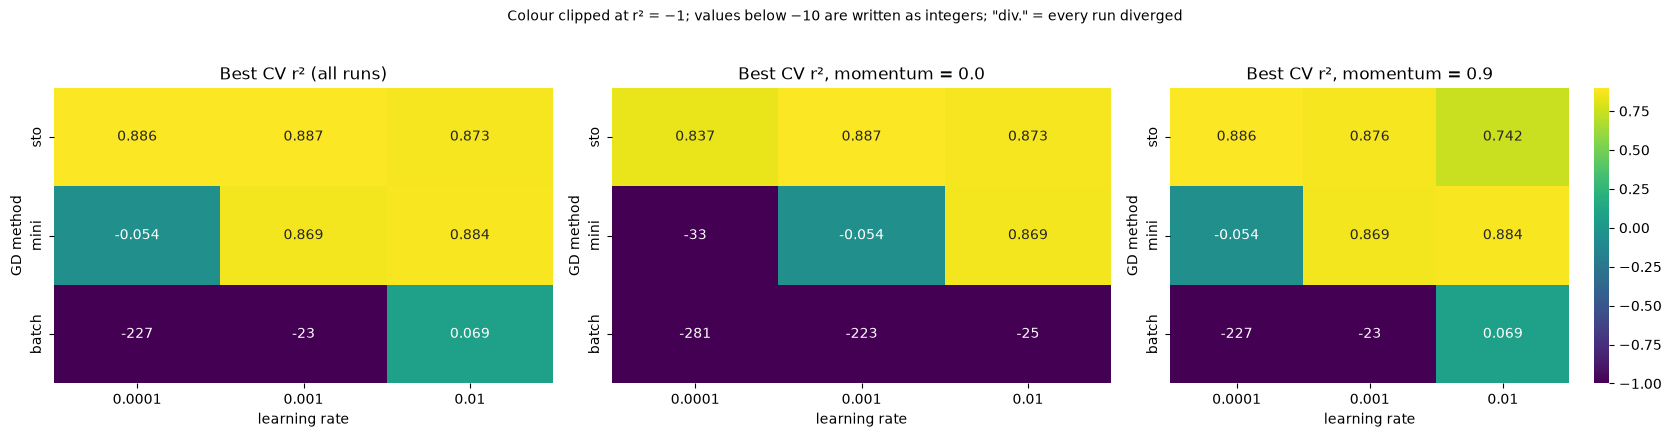

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
pv = res_df.pivot_table(index='method', columns='lr', values='cv_r2', aggfunc='max').loc[['sto', 'mini', 'batch']]
sns.heatmap(pv.clip(lower=-1), annot=pv.map(lambda v: f'{v:.3f}' if v > -10 else f'{v:.0f}'), fmt='',
            cmap='viridis', vmin=-1, vmax=0.9, ax=axes[0], cbar=False)
axes[0].set_title('Best CV r² (all runs)')
for ax, mom in zip(axes[1:], [0.0, 0.9]):
    sub = res_df[res_df.momentum == mom]
    pv = sub.pivot_table(index='method', columns='lr', values='cv_r2', aggfunc='max').reindex(['sto', 'mini', 'batch'])
    sns.heatmap(pv.clip(lower=-1), annot=pv.map(lambda v: 'div.' if pd.isna(v) else (f'{v:.3f}' if v > -10 else f'{v:.0f}')),
                fmt='', cmap='viridis', vmin=-1, vmax=0.9, ax=ax, cbar=(mom == 0.9))
    ax.set_title(f'Best CV r², momentum = {mom}')
for ax in axes:
    ax.set_xlabel('learning rate'); ax.set_ylabel('GD method')
plt.suptitle('Colour clipped at r² = −1; values below −10 are written as integers; "div." = every run diverged', y=1.03, fontsize=10)
plt.tight_layout()
plt.show()

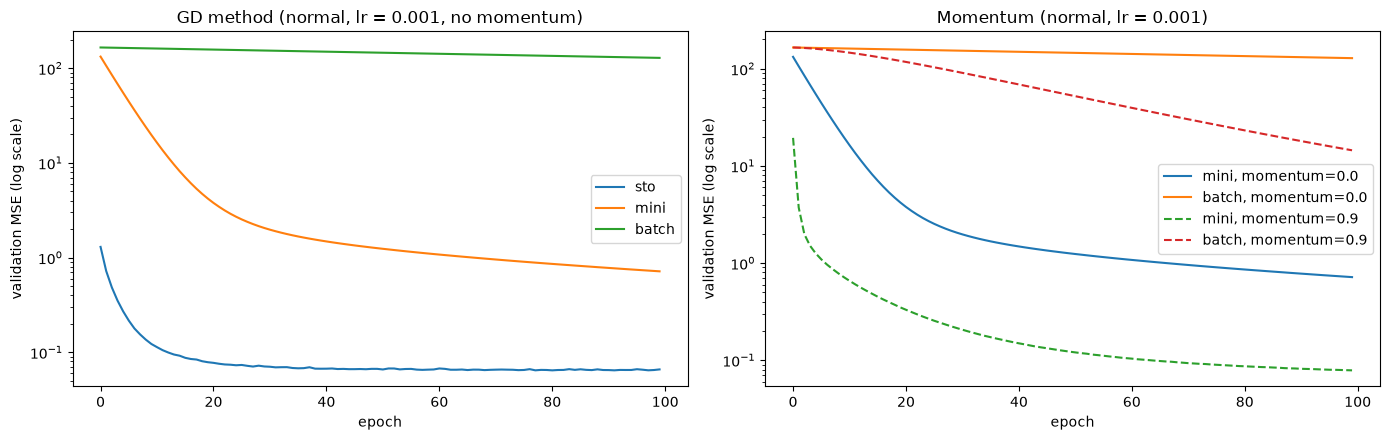

In [42]:
# Validation-loss curves (fold 0) for the normal model, zeros init: effect of method and of momentum
def curve(reg, method, lr, init, mom):
    return next(r['val_curve'] for r in results if (r['model'], r['method'], r['lr'], r['weight_init'], r['momentum']) == (reg, method, lr, init, mom))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for method in ['sto', 'mini', 'batch']:
    axes[0].plot(curve('normal', method, 0.001, 'zeros', 0.0), label=method)
axes[0].set_title('GD method (normal, lr = 0.001, no momentum)')
for mom, ls in [(0.0, '-'), (0.9, '--')]:
    for method in ['mini', 'batch']:
        axes[1].plot(curve('normal', method, 0.001, 'zeros', mom), ls, label=f'{method}, momentum={mom}')
axes[1].set_title('Momentum (normal, lr = 0.001)')
for ax in axes:
    ax.set_yscale('log'); ax.set_xlabel('epoch'); ax.set_ylabel('validation MSE (log scale)'); ax.legend()
plt.tight_layout()
plt.show()

### 10. Best model retrained on the full training set and tested on test set
The best settings are retrained with `fit_final` on all 5,444 training cars.
Test metrics are reported on the log scale and on the original price scale.

In [46]:
best = table.iloc[0]
best_cfg = dict(reg=best.model, method=best.method, lr=float(best.lr),
                weight_init=best.init, momentum=float(best.momentum))
print("Best configuration:", best_cfg)
print(f"CV MSE = {best.cv_mse:.4f}, CV r2 = {best.cv_r2:.4f}")

np.random.seed(RANDOM_STATE)
best_model = build_model(best_cfg['reg'], best_cfg['method'], best_cfg['lr'], best_cfg['weight_init'], best_cfg['momentum'])
best_model.fit_final(TRAIN_DATA[best_cfg['reg']], y_train_np)
print(f"Final training stopped after {len(best_model.train_history)} epochs")

X_te = TEST_DATA[best_cfg['reg']]
yhat_log = best_model.predict(X_te)
test_mse = best_model.mse(y_test_np, yhat_log)
test_r2  = best_model.r2(y_test_np, yhat_log)

# back to rupees
yhat_price, ytrue_price = np.exp(yhat_log), np.exp(y_test_np)
test_r2_price = best_model.r2(ytrue_price, yhat_price)
test_mae_price = np.abs(ytrue_price - yhat_price).mean()

# on the price scale a few very expensive cars dominate the squared error, so the median
# absolute error and the single worst case are reported next to r2 .
test_medae_price = np.median(np.abs(ytrue_price - yhat_price))
worst = int(np.argmax(np.abs(ytrue_price - yhat_price)))

print(f"\nTEST (log-price scale): MSE = {test_mse:.4f}   r2 = {test_r2:.4f}")
print(f"TEST (price scale)    : r2 = {test_r2_price:.4f}   MAE = {test_mae_price:,.0f}   median AE = {test_medae_price:,.0f}")
print(f"Worst single car      : actual {ytrue_price[worst]:,.0f}  predicted {yhat_price[worst]:,.0f}")

Best configuration: {'reg': 'polynomial', 'method': 'sto', 'lr': 0.001, 'weight_init': 'xavier', 'momentum': 0.0}
CV MSE = 0.0651, CV r2 = 0.8870
Final training stopped after 100 epochs

TEST (log-price scale): MSE = 0.0636   r2 = 0.8927
TEST (price scale)    : r2 = -0.6316   MAE = 103,552   median AE = 54,716
Worst single car      : actual 10,000,000  predicted 34,424,421


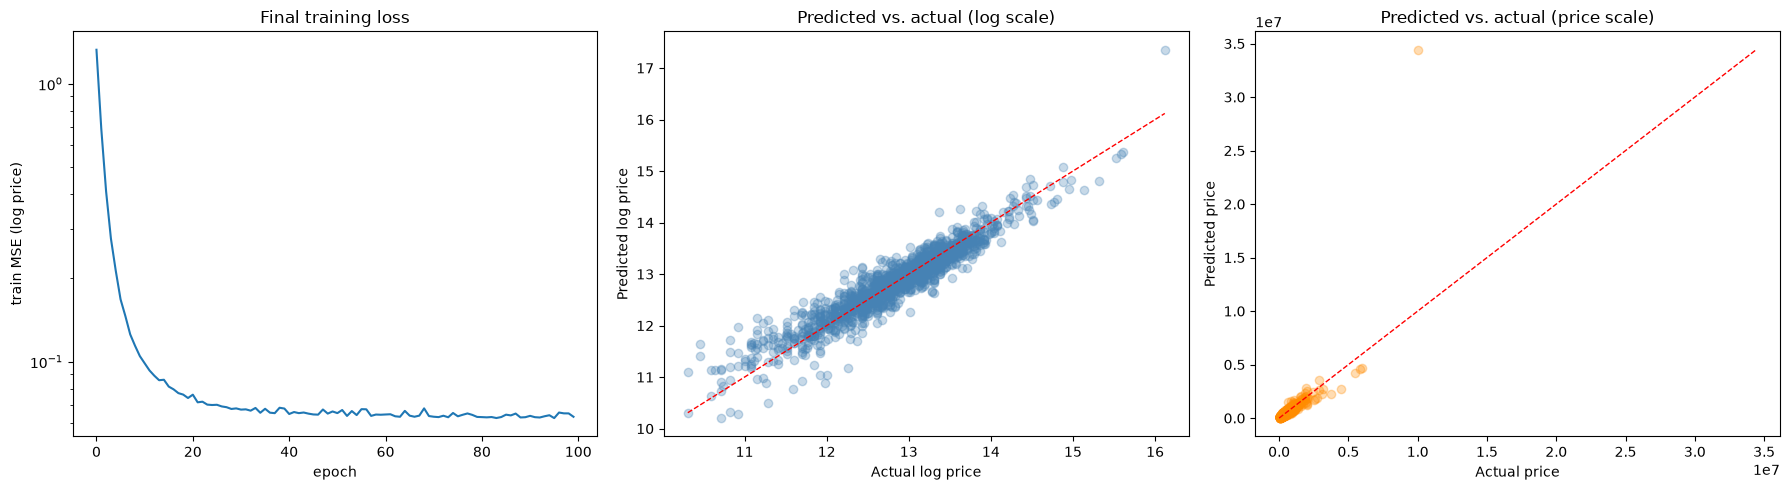

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(best_model.train_history)
axes[0].set_yscale('log'); axes[0].set_title('Final training loss'); axes[0].set_xlabel('epoch'); axes[0].set_ylabel('train MSE (log price)')

axes[1].scatter(y_test_np, yhat_log, alpha=0.3, color='steelblue')
lims = [y_test_np.min(), y_test_np.max()]
axes[1].plot(lims, lims, 'r--', linewidth=1)
axes[1].set_xlabel('Actual log price'); axes[1].set_ylabel('Predicted log price'); axes[1].set_title('Predicted vs. actual (log scale)')

axes[2].scatter(ytrue_price, yhat_price, alpha=0.3, color='darkorange')
lims = [0, max(ytrue_price.max(), yhat_price.max())]
axes[2].plot(lims, lims, 'r--', linewidth=1)
axes[2].set_xlabel('Actual price'); axes[2].set_ylabel('Predicted price'); axes[2].set_title('Predicted vs. actual (price scale)')
plt.tight_layout()
plt.show()

### 11. Feature importance

The bars are the learned coefficients, sorted by magnitude. Blue raises the predicted price and red lowers it. The numeric inputs are standardised, so a
numeric coefficient means "change in log price per one standard deviation of that feature". A brand/fuel/transmission coefficient is the
log-price shift for that category (its input is 0 or 1). The two kinds are therefore on comparable but not identical scales.

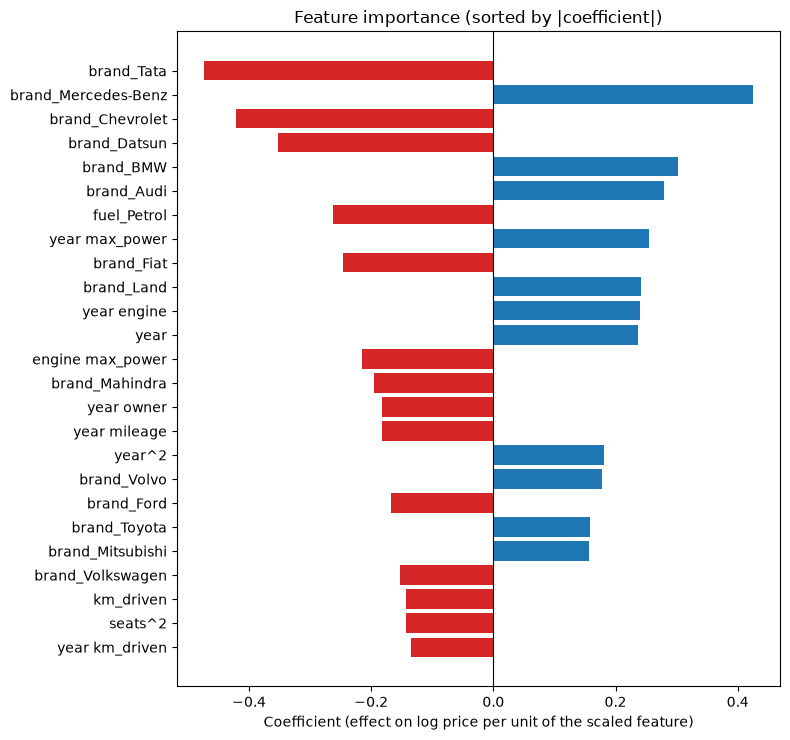

,feature,coefficient
62,brand_Tata,-0.4731
55,brand_Mercedes-Benz,0.4244
39,brand_Chevrolet,-0.4216
41,brand_Datsun,-0.3524
38,brand_BMW,0.3027
37,brand_Audi,0.2797
66,fuel_Petrol,-0.2619
11,year max_power,0.2544
42,brand_Fiat,-0.2457
51,brand_Land,0.2412


In [45]:
fig_imp = best_model.plot_feature_importance(feature_names=FEATURES[best_cfg['reg']], top_k=25)
plt.show()

coef_table = pd.DataFrame({'feature': FEATURES[best_cfg['reg']], 'coefficient': best_model._coef()})
coef_table['abs'] = coef_table.coefficient.abs()
coef_table.sort_values('abs', ascending=False).drop(columns='abs').head(12)

### 12. Log the final model to MLflow

The chosen model is logged as one more MLflow run (tagged `stage = final`) with its test metrics, its training-loss curve and
the feature-importance plot.

In [48]:
os.makedirs('model', exist_ok=True)
bundle = {
    'preprocessor': preprocessor_poly if best_cfg['reg'] == 'polynomial' else preprocessor,
    'theta': best_model.theta,
    'config': best_cfg,
    'feature_names': list(FEATURES[best_cfg['reg']]),
    'target': 'log(selling_price)',
    'test_metrics': {'mse_log': test_mse, 'r2_log': test_r2, 'r2_price': test_r2_price,
                     'mae_price': test_mae_price, 'medae_price': test_medae_price},
}
joblib.dump(bundle, 'model/car_price_model_a2.pkl')
fig_imp.savefig('model/feature_importance.png', dpi=120, bbox_inches='tight')

with mlflow.start_run(run_name=f"FINAL-{best_cfg['reg']}-{best_cfg['method']}-{best_cfg['weight_init']}-lr{best_cfg['lr']}-mom{best_cfg['momentum']}") as run:
    mlflow.set_tags({'stage': 'final', 'session': SESSION})
    mlflow.log_params({'model': best_cfg['reg'], 'method': best_cfg['method'], 'lr': best_cfg['lr'],
                       'weight_init': best_cfg['weight_init'], 'momentum': best_cfg['momentum'],
                       'lambda': LAMBDAS.get(best_cfg['reg']), 'num_epochs': NUM_EPOCHS, 'batch_size': BATCH_SIZE})
    mlflow.log_metrics({'cv_mse': float(best.cv_mse), 'cv_r2': float(best.cv_r2),
                        'test_mse': float(test_mse), 'test_r2': float(test_r2),
                        'test_r2_price': float(test_r2_price), 'test_mae_price': float(test_mae_price)})
    log_steps(run.info.run_id, 'train_loss', best_model.train_history)
    mlflow.log_artifact('model/car_price_model_a2.pkl')
    mlflow.log_artifact('model/feature_importance.png')
print("Saved model/car_price_model_a2.pkl and logged the FINAL run to MLflow")

Saved model/car_price_model_a2.pkl and logged the FINAL run to MLflow


## 13. Report


### Comparison table

I did not use the mean r² per factor because the runs that never converge go down to about −280 and destroy the average. So for
each factor I looked at the best r², the median, and how many runs got past 0.85.

| Factor | Level | Best CV r² | Median CV r² | Runs above 0.85 | Diverged |
|---|---|---|---|---|---|
| Model | polynomial | **0.8870** | −0.3044 | 12 / 36 | 2 |
| | normal | 0.8796 | 0.1022 | 14 / 36 | 0 |
| | lasso (λ=0.001) | 0.8773 | 0.1568 | 14 / 36 | 0 |
| | ridge (λ=0.01) | 0.8723 | 0.2915 | 14 / 36 | 0 |
| Method | stochastic | **0.8870** | 0.8669 | 30 / 48 | 2 |
| | mini-batch (50) | 0.8836 | 0.4011 | 24 / 48 | 0 |
| | batch | 0.0695 | −124.55 | 0 / 48 | 0 |
| Momentum | 0.9 | 0.8865 | **0.5414** | 31 / 72 | 2 |
| | 0.0 | 0.8870 | −0.2935 | 23 / 72 | 0 |
| Init | xavier | 0.8870 | 0.0493 | 26 / 72 | 1 |
| | zeros | 0.8866 | 0.0695 | 28 / 72 | 1 |
| Learning rate | 0.001 | 0.8870 | 0.3776 | 23 / 48 | 0 |
| | 0.01 | 0.8836 | 0.8433 | 23 / 48 | 2 |
| | 0.0001 | 0.8865 | −16.59 | 8 / 48 | 0 |

Top 5 out of the 144 runs:

| # | Model | Method | lr | Init | Momentum | CV MSE | CV r² |
|---|---|---|---|---|---|---|---|
| 1 | polynomial | sto | 0.001 | xavier | 0.0 | 0.0651 | 0.8870 |
| 2 | polynomial | sto | 0.001 | zeros | 0.0 | 0.0653 | 0.8866 |
| 3 | polynomial | sto | 0.0001 | zeros | 0.9 | 0.0654 | 0.8865 |
| 4 | polynomial | sto | 0.0001 | xavier | 0.9 | 0.0657 | 0.8857 |
| 5 | polynomial | mini | 0.01 | zeros | 0.9 | 0.0670 | 0.8836 |

From MLflow screenshot:

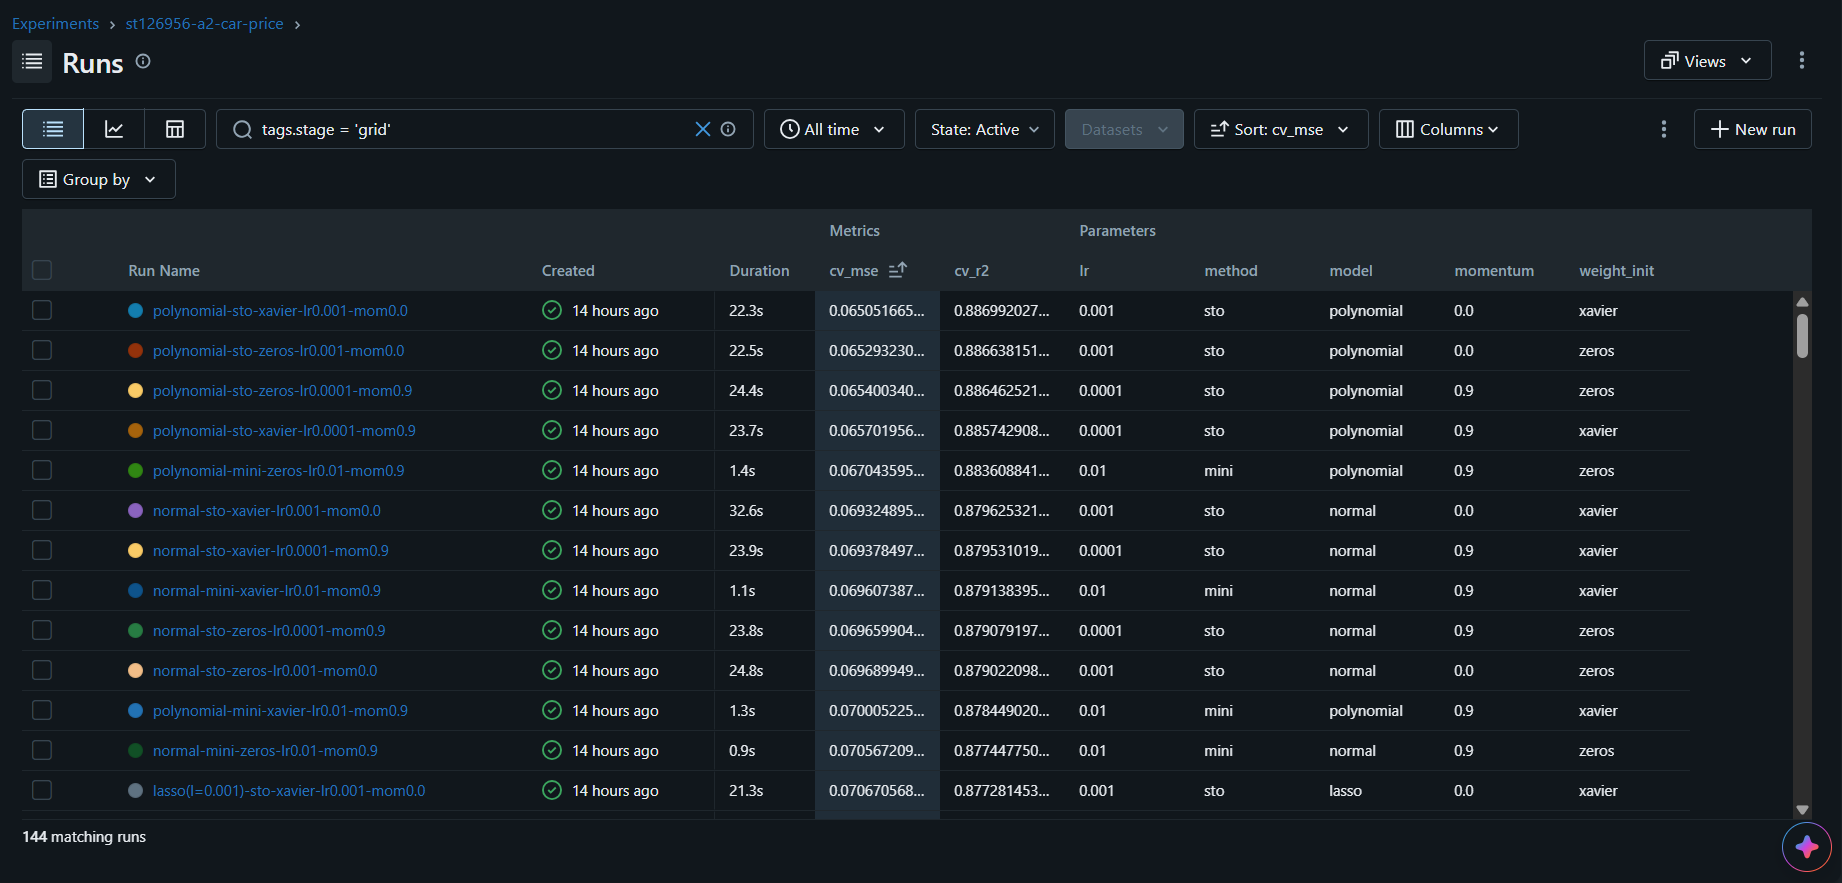

Best model: polynomial features, stochastic GD, lr = 0.001, xavier, no momentum. CV MSE 0.0651 and CV r² 0.8870.
On the test set it got **MSE 0.0636 and r² 0.8927** on the log-price scale and **r2 = -0.6316   MAE = 103,552   median AE = 54,716** on the original price scale

### Findings

1. Batch GD simply never got anywhere. The best batch run out of 48 was r² = 0.0695, and at lr = 0.0001 it
reached −281. A negative median r² here just means the model
is still worse than predicting the average. Even after comparing the top 10 runs (screenshot below), No batch run appears at all, only sto and mini.

2. **Momentum is basically a bigger learning rate.**  With momentum 0.9 the
velocity adds up to about 1 + 0.9 + 0.9² + ... = 10 times the plain step, and the results follow that almost exactly:

| normal model, mini-batch | momentum 0.0 | momentum 0.9 |
|---|---|---|
| lr = 0.01 | 0.8559 | 0.8774 |
| lr = 0.001 | −0.2847 | 0.8562 |
| lr = 0.0001 | −34.12 | −0.2849 |

So momentum with lr = 0.001 is
about the same as no momentum with lr = 0.01. That is why momentum helped the slow settings so much (median r² went from −0.29 to
0.54) but hurt the ones that were already taking big steps: stochastic at lr = 0.01 dropped from 0.870 to 0.378, and the only two
runs in the entire grid that diverged were polynomial + stochastic + lr = 0.01 + momentum 0.9, which overflowed after 2 epochs.
So momentum is not something you can just switch on, you have to lower the learning rate with it.

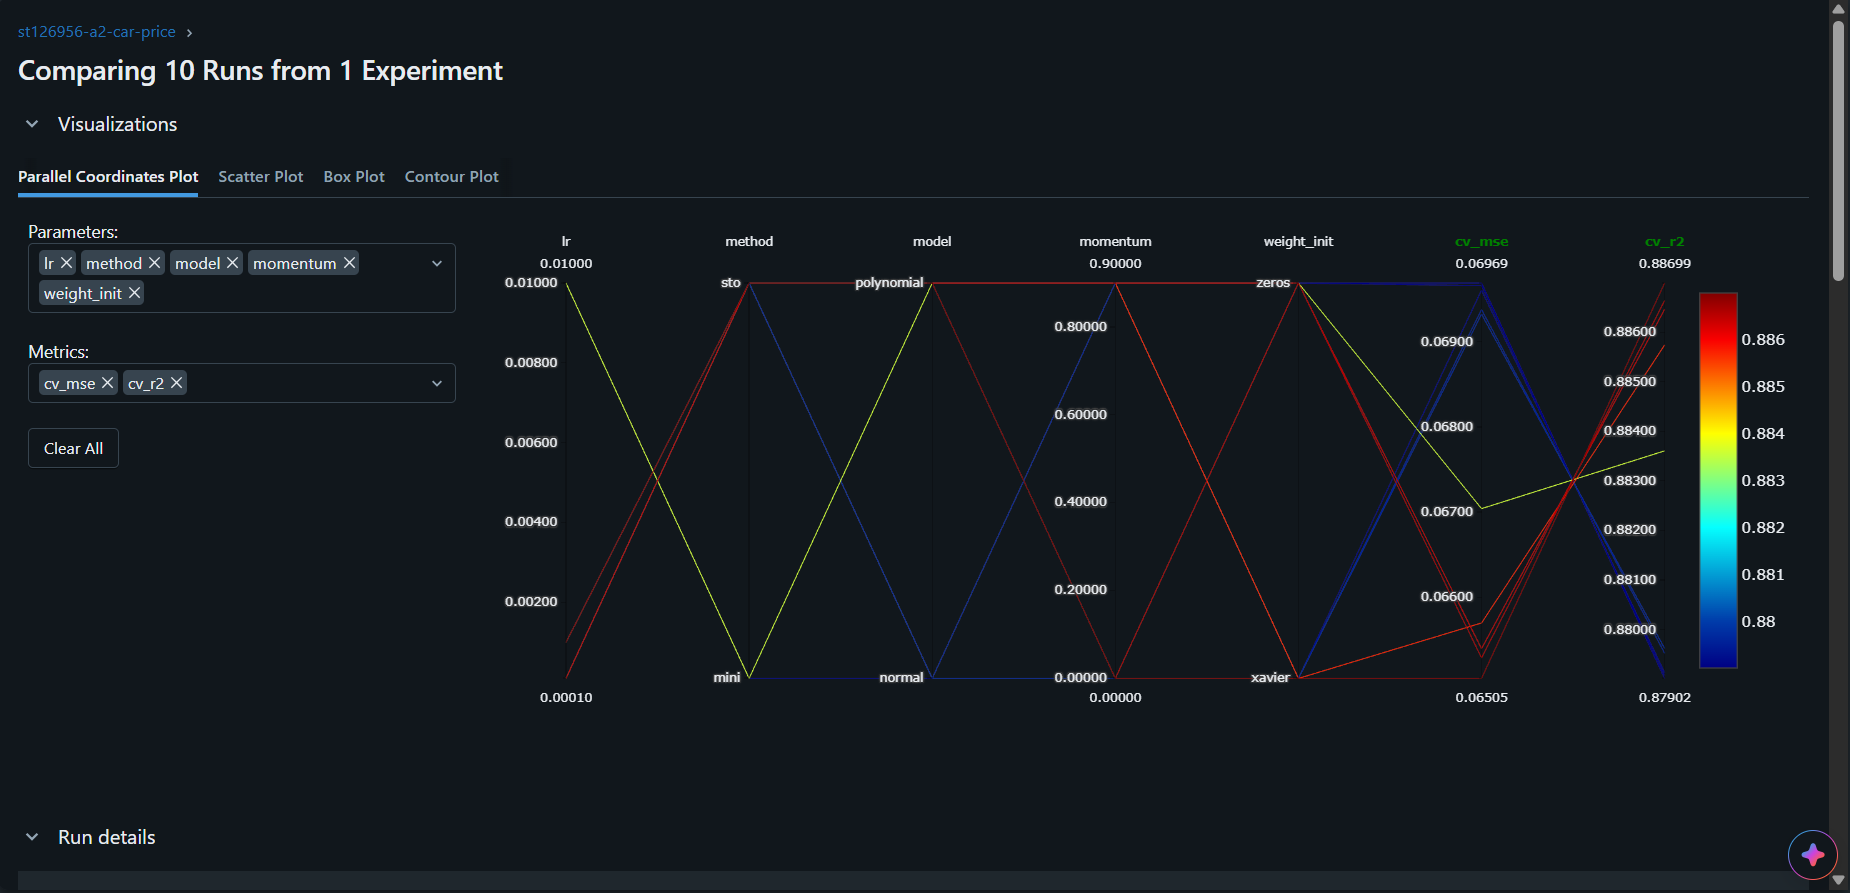

Even from comparing the top 10 runs, they split into two equally good groups: momentum 0.9 with a small learning rate, or no momentum with a ten times larger one.

3. **Xavier vs zeros made almost no difference.** I think because Xavier is meant for
deep networks where the signal has to pass through many layers without shrinking or exploding, and we only have one layer here.

4. **Regularisation did not help at all.** Plain regression (0.8796) beat both ridge (0.8723) and lasso (0.8773), and in the lambda
search the biggest lambda was always the worst.

5. **Polynomial features gave the best model but also the least stable one.** Adding degree-2 terms of the 7 numeric columns (70
features instead of 42) pushed the best r² from 0.8796 to 0.8870. The interactions `year × max_power` and `year × engine` both
show up among the strongest coefficients, which is intuitive. But the polynomial block also had the worst median (−0.3044) and both of the diverged runs, because the extra correlated features make the gradients bigger.

6. **r² values on the test set.** On the log scale the model gets r² = 0.8927, but on the rupee scale it comes out as
−0.63. It turns out one test sample's actual price is 10,000,000 and the model predicts
34,424,421. The five worst cars together make up about 96% of the total squared error. The median absolute error is around 55,000,
so normal predictions are fine. The reason is that `exp()` turns a moderate error in log space into a massive error in rupees at
the top end, and a linear model can extrapolate above the most expensive car it ever saw.


##### The `FINAL-polynomial-sto-xavier-lr0.001-mom0.0` run with the test metrics is attached from MLflow interface as well.
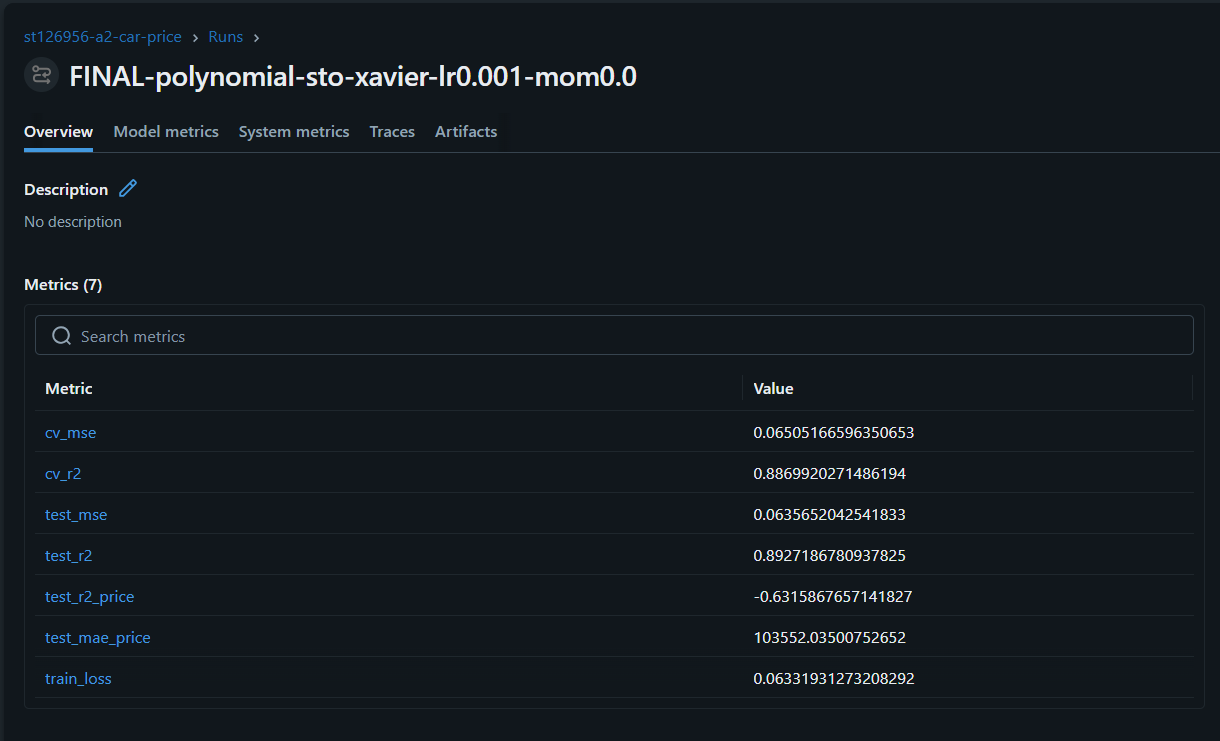